Sarah Zahaykevich
Sinkhole Prediction — Random Forest Model
NYC 500m Grid

## Problem Definition

This project predicts whether a given 500m x 500m grid cell in New York City will experience a sinkhole-related cave-in complaint in a given month. The model uses a Random Forest classifier trained on temporal and spatial features derived from 311 cave-in complaints, water main breaks, precipitation, bedrock depth, and pavement ratings. Each observation represents one grid cell for one month. The binary target is whether at least one cave-in complaint was recorded in that cell that month.

In [1]:
# Import core libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score, roc_auc_score)
from imblearn.over_sampling import SMOTE

BASE = r'C:\Users\szaha\anaconda_projects\7bddeb11-5afb-41ab-a725-816dd757e48f'

## 1. Load Feature Files

In [2]:
df_311   = pd.read_csv(os.path.join(BASE, 'features_311_grid.csv'))
df_water = pd.read_csv(os.path.join(BASE, 'features_water_grid.csv'))
df_prcp  = pd.read_csv(os.path.join(BASE, 'features_precipitation_grid.csv'))
df_pave  = pd.read_csv(os.path.join(BASE, 'features_pavement_grid.csv'))
df_bed   = pd.read_csv(os.path.join(BASE, 'features_bedrock_grid.csv'))

print('311 features:          ', df_311.shape)
print('Water features:        ', df_water.shape)
print('Precipitation features:', df_prcp.shape)
print('Pavement features:     ', df_pave.shape)
print('Bedrock features:      ', df_bed.shape)

311 features:           (263978, 6)
Water features:         (263978, 5)
Precipitation features: (263978, 4)
Pavement features:      (256542, 3)
Bedrock features:       (3718, 3)


## 2. Merge All Features

In [3]:
# Start from 311 panel (base grid_id x year_month scaffold)
df = df_311.copy()

# Merge time-varying features on grid_id + year_month
df = df.merge(df_water[['grid_id', 'year_month', 'breaks_last_month', 'breaks_last_3_months']],
              on=['grid_id', 'year_month'], how='left')

df = df.merge(df_prcp[['grid_id', 'year_month', 'monthly_rain', 'rain_last_3_months']],
              on=['grid_id', 'year_month'], how='left')

df = df.merge(df_pave[['grid_id', 'year_month', 'pavement_rating']],
              on=['grid_id', 'year_month'], how='left')

# Merge static bedrock features on grid_id only
df = df.merge(df_bed[['grid_id', 'elev_ft', 'depth_ft']],
              on='grid_id', how='left')

print(f'Merged dataset shape: {df.shape}')
df.head()

Merged dataset shape: (263978, 13)


,grid_id,year_month,complaint_count,month,prior_month_complaints,complaints_in_last_3months,breaks_last_month,breaks_last_3_months,monthly_rain,rain_last_3_months,pavement_rating,elev_ft,depth_ft
0,0,2020-01,0,1,0,0,0,0,1.93,15.19,6.4991,-211.05,343.05
1,0,2020-02,0,2,0,0,0,0,2.54,10.97,6.4991,-211.05,343.05
2,0,2020-03,0,3,0,0,0,0,3.78,11.56,6.4991,-211.05,343.05
3,0,2020-04,0,4,0,0,0,0,4.49,8.25,6.4991,-211.05,343.05
4,0,2020-05,0,5,0,0,0,0,1.65,10.81,6.4991,-211.05,343.05


## 3. Create Target Variable

In [4]:
# Binary target: 1 if the cell had at least one cave-in complaint that month
df['has_sinkhole'] = (df['complaint_count'] > 0).astype(int)

print('Target distribution:')
print(df['has_sinkhole'].value_counts())
print(f'\nPositive rate: {df["has_sinkhole"].mean():.4%}')

Target distribution:
has_sinkhole
0    233977
1     30001
Name: count, dtype: int64

Positive rate: 11.3650%


In [5]:
# Drop the first 3 months so all rolling features have a full history window
df = df[df['year_month'] >= '2020-04'].reset_index(drop=True)

# Drop any remaining nulls
before = len(df)
df = df.dropna().reset_index(drop=True)
print(f'Dropped {before - len(df)} rows with nulls | Final shape: {df.shape}')

Dropped 7436 rows with nulls | Final shape: (245388, 14)


## 4. Exploratory Data Analysis

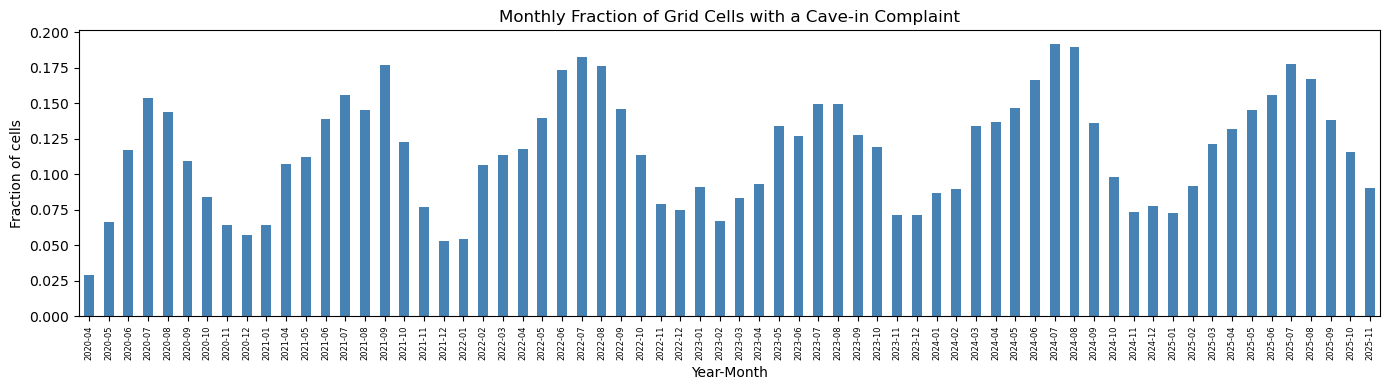

In [6]:
# Monthly sinkhole complaint rate across all cells
monthly_rate = df.groupby('year_month')['has_sinkhole'].mean()

plt.figure(figsize=(14, 4))
monthly_rate.plot(kind='bar', color='steelblue', edgecolor='none')
plt.title('Monthly Fraction of Grid Cells with a Cave-in Complaint')
plt.xlabel('Year-Month')
plt.ylabel('Fraction of cells')
plt.xticks(rotation=90, fontsize=6)
plt.tight_layout()
plt.show()

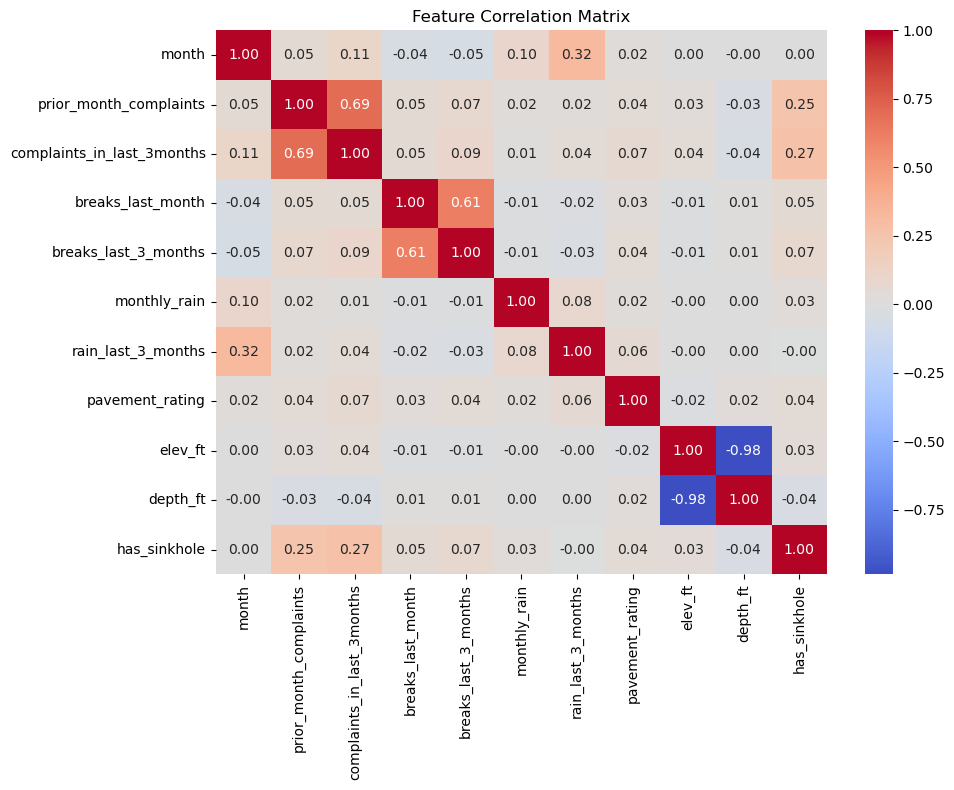

In [7]:
# Feature correlation heatmap
feature_columns = [
    'month',
    'prior_month_complaints',
    'complaints_in_last_3months',
    'breaks_last_month',
    'breaks_last_3_months',
    'monthly_rain',
    'rain_last_3_months',
    'pavement_rating',
    'elev_ft',
    'depth_ft'
]

plt.figure(figsize=(10, 8))
sns.heatmap(df[feature_columns + ['has_sinkhole']].corr(),
            annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## 5. Train / Test Split (Temporal)

In [8]:
# Temporal split: train on everything before 2024-01, test on 2024-01 onward
# This mirrors real-world use — the model never sees future data during training
cutoff_date = '2024-01'

train = df[df['year_month'] <  cutoff_date]
test  = df[df['year_month'] >= cutoff_date]

X_train = train[feature_columns]
y_train = train['has_sinkhole']
X_test  = test[feature_columns]
y_test  = test['has_sinkhole']

print(f'Train: {X_train.shape} | positives: {y_train.sum()} ({y_train.mean():.2%})')
print(f'Test:  {X_test.shape}  | positives: {y_test.sum()} ({y_test.mean():.2%})')

Train: (159874, 10) | positives: 17619 (11.02%)
Test:  (85514, 10)  | positives: 10915 (12.76%)


## 6. SMOTE — Handle Class Imbalance

In [9]:
# Apply SMOTE to training set only — never to test set
smote = SMOTE(random_state=42, sampling_strategy=0.5)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f'Before SMOTE: {y_train.value_counts().to_dict()}')
print(f'After  SMOTE: {pd.Series(y_train_res).value_counts().to_dict()}')

Before SMOTE: {0: 142255, 1: 17619}
After  SMOTE: {0: 142255, 1: 71127}


## 7. Train Random Forest

In [10]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_res, y_train_res)
print('Model trained.')

Model trained.


In [11]:
# Cross-validation F1 on the resampled training set
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X_train_res, y_train_res,
                             cv=cv, scoring='f1', n_jobs=-1)

print(f'Cross-validation F1 scores: {cv_scores.round(4)}')
print(f'Mean F1: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})')

Cross-validation F1 scores: [0.701  0.7073 0.7017 0.7022 0.6998]
Mean F1: 0.7024 (+/- 0.0026)


## 8. Evaluate Model

In [12]:
y_train_pred = rf.predict(X_train)
y_test_pred  = rf.predict(X_test)

print('=== TRAINING SET ===')
print(classification_report(y_train, y_train_pred, target_names=['No Sinkhole', 'Sinkhole']))

print('=== TEST SET ===')
print(classification_report(y_test, y_test_pred, target_names=['No Sinkhole', 'Sinkhole']))

=== TRAINING SET ===
              precision    recall  f1-score   support

 No Sinkhole       0.96      0.74      0.84    142255
    Sinkhole       0.26      0.74      0.39     17619

    accuracy                           0.74    159874
   macro avg       0.61      0.74      0.61    159874
weighted avg       0.88      0.74      0.79    159874

=== TEST SET ===
              precision    recall  f1-score   support

 No Sinkhole       0.96      0.42      0.59     74599
    Sinkhole       0.18      0.88      0.30     10915

    accuracy                           0.48     85514
   macro avg       0.57      0.65      0.44     85514
weighted avg       0.86      0.48      0.55     85514



In [13]:
# Check for overfitting by comparing train vs test F1
train_f1 = f1_score(y_train, y_train_pred)
test_f1  = f1_score(y_test,  y_test_pred)
test_auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])

print(f'Train F1:  {train_f1:.4f}')
print(f'Test  F1:  {test_f1:.4f}')
print(f'Test  AUC: {test_auc:.4f}')

Train F1:  0.3898
Test  F1:  0.3018
Test  AUC: 0.7248


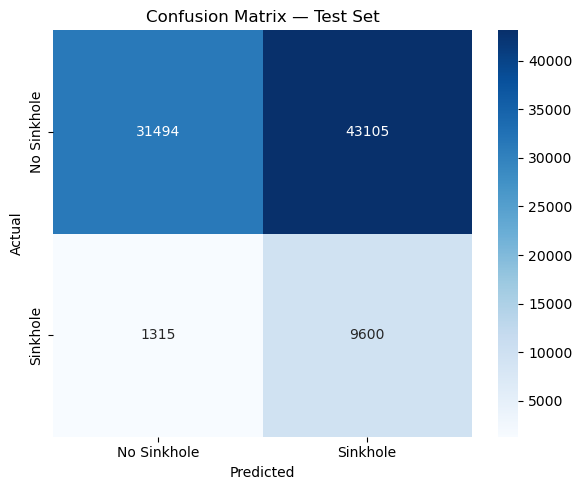

In [14]:
# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Sinkhole', 'Sinkhole'],
            yticklabels=['No Sinkhole', 'Sinkhole'])
plt.title('Confusion Matrix — Test Set')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## 9. Feature Importance

C:\Users\szaha\AppData\Local\Temp\ipykernel_51204\3063156612.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp, x='Importance', y='Feature', palette='viridis')


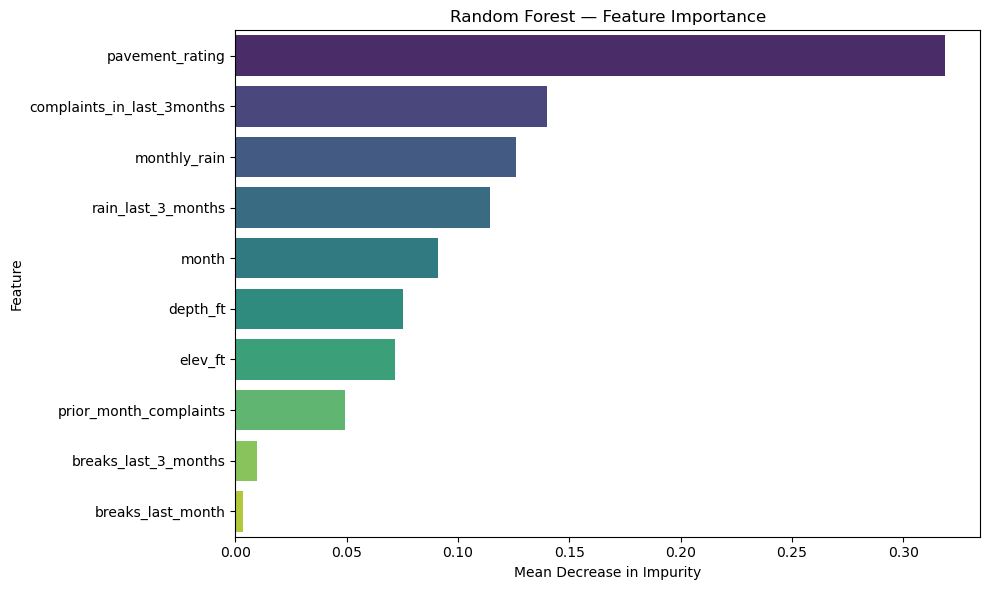

                   Feature  Importance
           pavement_rating    0.318438
complaints_in_last_3months    0.140057
              monthly_rain    0.126129
        rain_last_3_months    0.114523
                     month    0.090982
                  depth_ft    0.075307
                   elev_ft    0.071930
    prior_month_complaints    0.049221
      breaks_last_3_months    0.009867
         breaks_last_month    0.003545


In [15]:
feat_imp = pd.DataFrame({
    'Feature':    feature_columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp, x='Importance', y='Feature', palette='viridis')
plt.title('Random Forest — Feature Importance')
plt.xlabel('Mean Decrease in Impurity')
plt.tight_layout()
plt.show()

print(feat_imp.to_string(index=False))

## 10. Predictions on the Most Recent Month

In [16]:
latest_month = df['year_month'].max()
df_latest = df[df['year_month'] == latest_month].copy()

df_latest['sinkhole_probability'] = rf.predict_proba(df_latest[feature_columns])[:, 1]
df_latest['prediction']           = rf.predict(df_latest[feature_columns])
df_latest['prediction_label']     = df_latest['prediction'].map({
    0: 'No Sinkhole Expected',
    1: 'Sinkhole Risk'
})

print(f'Predictions for: {latest_month}')
print(f'Cells flagged as at-risk: {df_latest["prediction"].sum():,} / {len(df_latest):,}')
df_latest[['grid_id', 'sinkhole_probability', 'prediction_label']] \
    .sort_values('sinkhole_probability', ascending=False).head(20)

Predictions for: 2025-11
Cells flagged as at-risk: 429 / 3,718


,grid_id,sinkhole_probability,prediction_label
88043,1333,0.753292,Sinkhole Risk
107909,1634,0.735401,Sinkhole Risk
164405,2490,0.731485,Sinkhole Risk
63953,968,0.731370,Sinkhole Risk
159851,2421,0.729767,Sinkhole Risk
173645,2630,0.727888,Sinkhole Risk
117941,1786,0.720210,Sinkhole Risk
143417,2172,0.716999,Sinkhole Risk
93521,1416,0.716694,Sinkhole Risk
155693,2358,0.715860,Sinkhole Risk


In [17]:
output_path = os.path.join(BASE, 'predictions_latest_month.csv')
df_latest[['grid_id', 'year_month', 'sinkhole_probability', 'prediction_label']] \
    .to_csv(output_path, index=False)
print(f'Saved to {output_path}')

Saved to C:\Users\szaha\anaconda_projects\7bddeb11-5afb-41ab-a725-816dd757e48f\predictions_latest_month.csv


## 11. Sinkhole Risk Map — Predicted Cells

In [18]:
import geopandas as gpd

# Load the NYC grid geometry
nyc = gpd.read_file(r"C:\Users\szaha\Downloads\Borough_Boundaries_20260328.geojson").to_crs(epsg=32618)
nyc_union = nyc.dissolve().reset_index(drop=True)

# Rebuild grid_clipped (same as featureEngineering.ipynb)
import numpy as np
from shapely.geometry import box

xmin, ymin, xmax, ymax = nyc_union.total_bounds
cell_size = 500
grid_cells = [box(x, y, x + cell_size, y + cell_size)
              for x in np.arange(xmin, xmax, cell_size)
              for y in np.arange(ymin, ymax, cell_size)]

grid = gpd.GeoDataFrame(geometry=grid_cells, crs=nyc_union.crs)
grid_clipped = gpd.overlay(grid, nyc_union, how='intersection')
grid_clipped['grid_id'] = range(len(grid_clipped))

print(f'Grid cells: {len(grid_clipped):,}')

Grid cells: 3,718


In [19]:
# Merge predictions onto grid geometry
grid_pred = grid_clipped[['grid_id', 'geometry']].merge(
    df_latest[['grid_id', 'sinkhole_probability', 'prediction']],
    on='grid_id', how='left'
)

# Cells with no features (outside panel) treated as no-risk
grid_pred['prediction']          = grid_pred['prediction'].fillna(0).astype(int)
grid_pred['sinkhole_probability'] = grid_pred['sinkhole_probability'].fillna(0)

at_risk   = grid_pred[grid_pred['prediction'] == 1]
not_at_risk = grid_pred[grid_pred['prediction'] == 0]

print(f'Predicted at-risk cells:  {len(at_risk):,}')
print(f'Predicted safe cells:     {len(not_at_risk):,}')

Predicted at-risk cells:  429
Predicted safe cells:     3,289


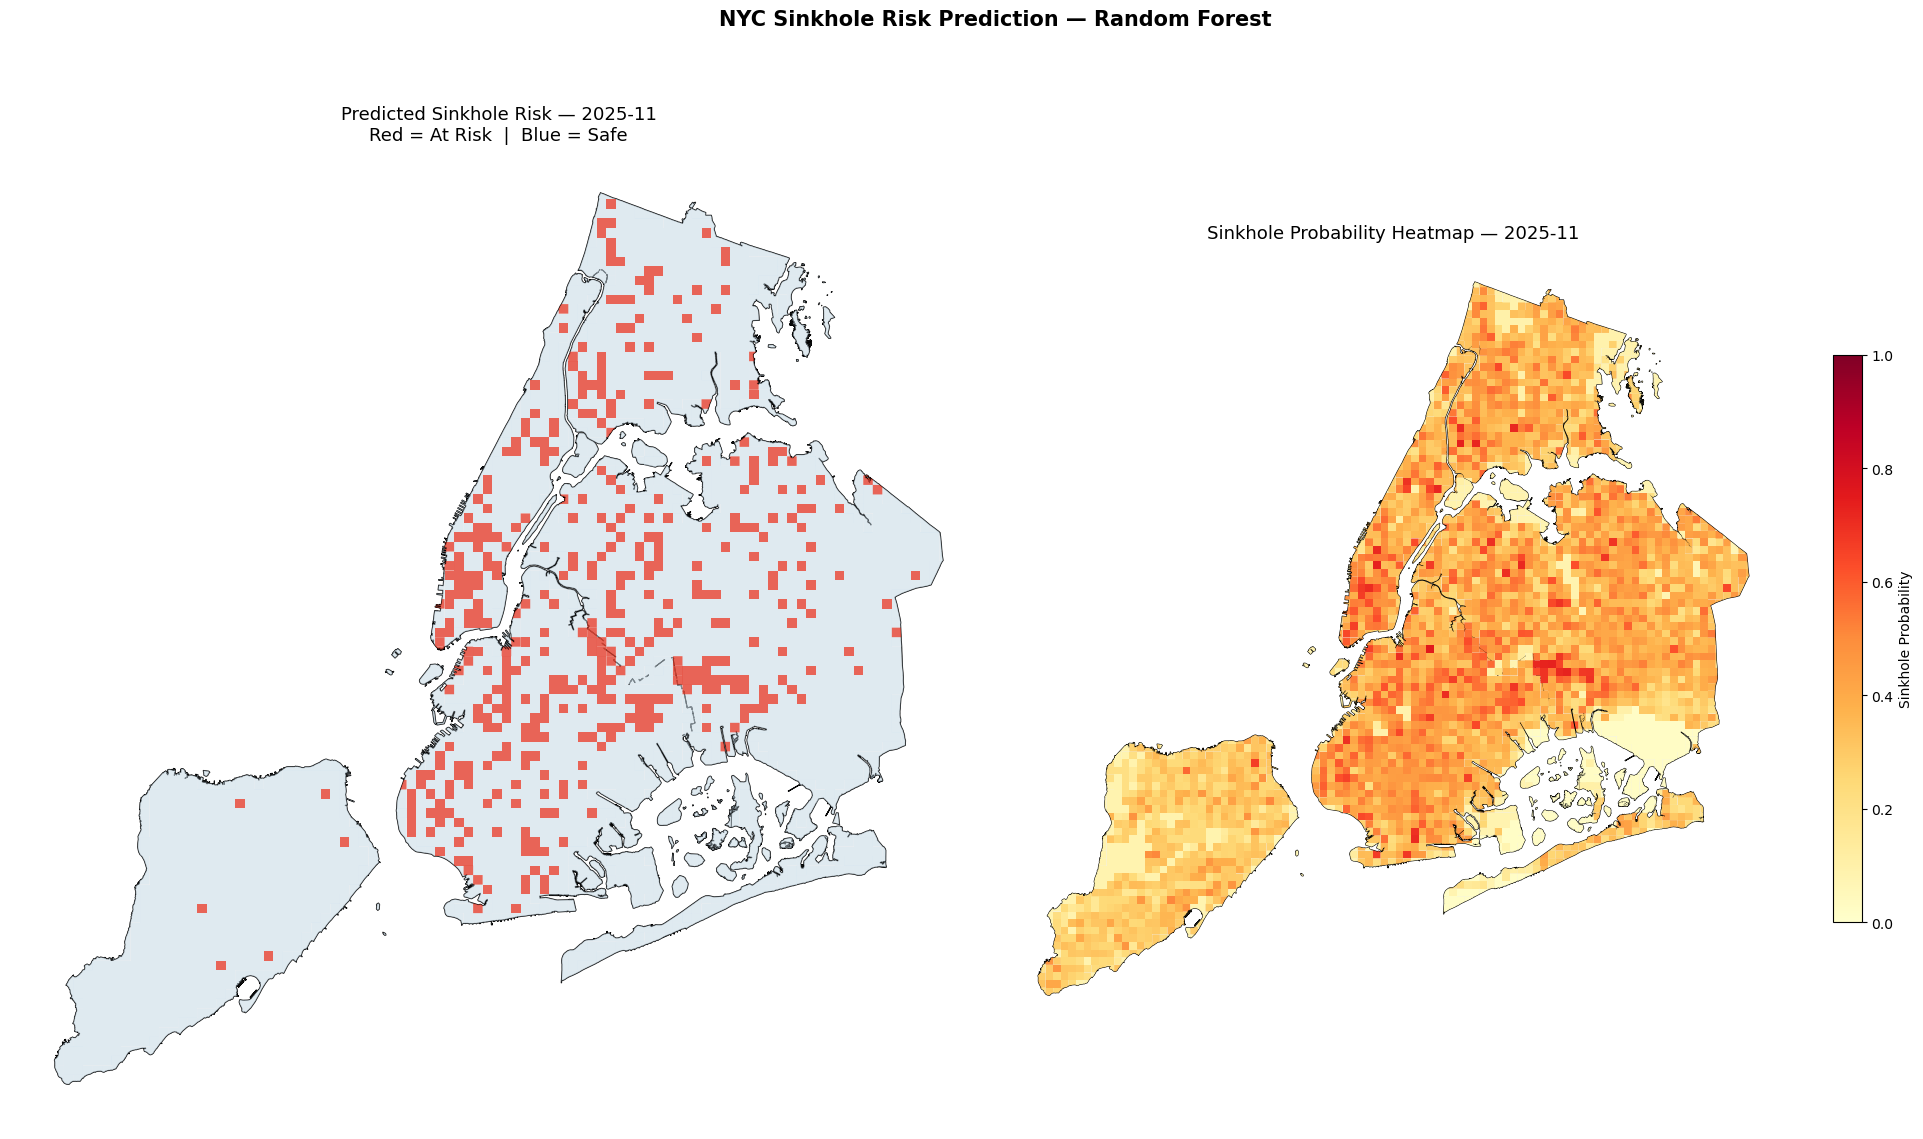

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(20, 12))

# ── Left panel: binary prediction (at-risk vs safe) ─────────────────────────
ax1 = axes[0]
nyc_union.plot(ax=ax1, facecolor='#f0f0f0', edgecolor='black', linewidth=0.8)
not_at_risk.plot(ax=ax1, facecolor='#d4e6f1', edgecolor='none', alpha=0.6)
at_risk.plot(ax=ax1, facecolor='#e74c3c', edgecolor='none', alpha=0.85)
ax1.set_title(f'Predicted Sinkhole Risk — {latest_month}\n'
              f'Red = At Risk  |  Blue = Safe',
              fontsize=13)
ax1.set_axis_off()

# ── Right panel: probability heatmap ─────────────────────────────────────────
ax2 = axes[1]
nyc_union.plot(ax=ax2, facecolor='#f0f0f0', edgecolor='black', linewidth=0.8)
grid_pred[grid_pred['sinkhole_probability'] > 0].plot(
    ax=ax2,
    column='sinkhole_probability',
    cmap='YlOrRd',
    vmin=0, vmax=1,
    edgecolor='none',
    legend=True,
    legend_kwds={'label': 'Sinkhole Probability', 'shrink': 0.5}
)
ax2.set_title(f'Sinkhole Probability Heatmap — {latest_month}',
              fontsize=13)
ax2.set_axis_off()

plt.suptitle('NYC Sinkhole Risk Prediction — Random Forest', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Model Strengths, Weaknesses, and Limitations

The Random Forest classifier predicts sinkhole risk at the 500m grid-cell level across all NYC boroughs. Key strengths include its ability to capture non-linear relationships between features and its robustness to outliers. SMOTE was applied to address the heavy class imbalance inherent in the data — sinkholes are rare events. The temporal train/test split ensures the model is evaluated in a realistic forward-looking scenario rather than leaking future information into training.

Limitations include the use of 311 cave-in complaints as a sinkhole proxy, which may miss unreported events. Bedrock depth is static and sparse, estimated via nearest-neighbour interpolation for most cells. Precipitation comes from a single Central Park station and does not capture spatial variation in rainfall.